In [49]:
import torch
from PIL import Image

from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

In [2]:
# old_prompt = """
# Your task is to write several texts based on this image. The first is a description of the overall image. This will be the prompt for a tex-to-video generative model.
# The other texts are descriptions of the characters in the image, so the number is variable.
# The texts of these descriptions should match the corresponding descriptions in the overall prompt as closely as possible.

# The output should be in JSON format. The key for the overall prompt should be just "prompt".
# For the decriptions the character, the key should be "characters" and the value should be an array of strings what contains each text.
# """

In [14]:
prompt = """
You are given an image. Produce a single JSON object with exactly two keys:

1) "prompt" — a scene description optimized for a text-to-video model.
   - Describe: setting, time of day, overall mood, dominant colors/lighting, camera framing/shot type, and visual style (e.g., "photoreal", "2D cel-shaded", "cinematic").
   - Camera must be static: include phrasing such as "static camera" or "fixed frame". Do NOT include any camera movement (no dolly, pan, tilt, zoom) and do NOT specify any video duration.
   - Include short descriptions of every visible character inside this overall prompt. For each character, include only: appearance, clothing, and facial expression.

2) "characters" — an array of objects. Each object contains a bounding box of the character's head only (not the whole body) and the matching description. Each object must have the following keys:
   {
     "bbox": [x_min, y_min, x_max, y_max],
     "description": "<string>"
   }
   - "bbox" represents the top-left and bottom-right pixel coordinates of the character’s head:
     - x_min, y_min = top-left corner of the head in pixels
     - x_max, y_max = bottom-right corner of the head in pixels
   - "description" must be a single-sentence expression, without a final period, containing only appearance, clothing, and facial expression
   - Descriptions must match (exactly or nearly exactly) the corresponding character text included in the overall "prompt"
   - If a visible character’s head is not clearly visible, omit that object
   - There is no required ordering for the array

Output requirements:
- The response must be valid JSON only, with exactly the following top-level structure:
  {
    "prompt": "<overall scene prompt string>",
    "characters": [
      {"bbox": [x_min, y_min, x_max, y_max], "description": "<char1 description>"},
      {"bbox": [x_min, y_min, x_max, y_max], "description": "<char2 description>"},
      ...
    ]
  }
- Do NOT wrap the JSON output in Markdown or code fences — output the raw JSON only (no ``` or other fences)
- Do not include extra keys, comments, or explanatory text before or after the JSON
"""

In [36]:
prompt = """
- Determine the bounding boxes of the faces that you detect in this image
- Do NOT wrap the JSON output in Markdown or code fences — output the raw JSON only (no ``` or other fences)
- Do not include extra keys, comments, or explanatory text before or after the JSON
"""

In [51]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-7B-Instruct",
    dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
    device_map="auto",
)

# default processer
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", use_fast=False)

# The default range for the number of visual tokens per image in the model is 4-16384.
# You can set min_pixels and max_pixels according to your needs, such as a token range of 256-1280, to balance performance and cost.
# min_pixels = 256*28*28
# max_pixels = 1280*28*28
# processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", min_pixels=min_pixels, max_pixels=max_pixels)

img = Image.open("examples/transformed.jpg")


messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": prompt},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
input_h = inputs['image_grid_thw'][0][1].item() * 14
input_w = inputs['image_grid_thw'][0][2].item() * 14
input_wh = (input_w, input_h)
resolution_wh = img.size

inputs = inputs.to("cuda")


# Inference: Generation of the output
# generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids = model.generate(**inputs, max_new_tokens=5_000)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 7724.32it/s]


['```json\n[\n\t{"bbox_2d": [319, 78, 420, 425], "label": "faces"},\n\t{"bbox_2d": [156, 82, 276, 440], "label": "faces"}\n]\n```']


In [52]:
input_wh, resolution_wh

((840, 476), (832, 480))

In [41]:
input_h, input_w

(tensor(476), tensor(840))

In [38]:
import json
import re

cleaned = re.sub(r"^```(?:json)?\n|```$", "", output_text[0].strip(), flags=re.MULTILINE)
data = json.loads(cleaned)

In [39]:
data

[{'bbox_2d': [319, 78, 420, 425], 'label': 'faces'},
 {'bbox_2d': [156, 82, 276, 440], 'label': 'faces'}]

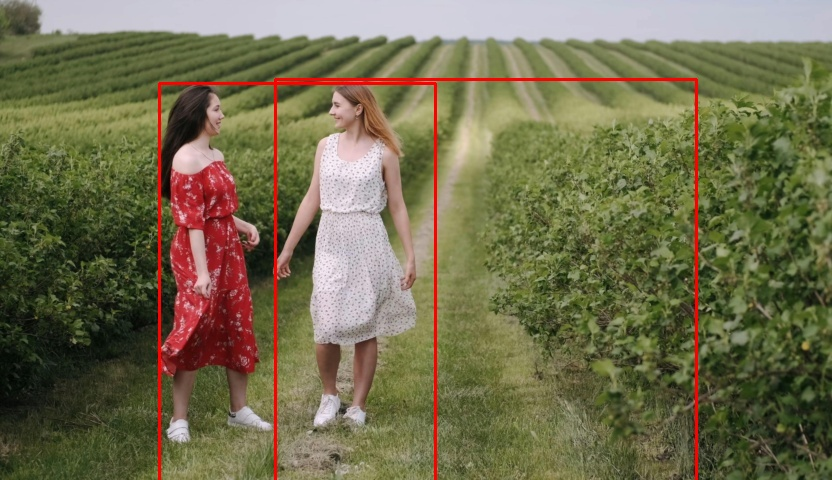

In [35]:
import cv2
from IPython.display import Image, display
import tempfile

# Load the image
image = cv2.imread("examples/transformed.jpg")

# Example bounding boxes: [(x, y, width, height), ...]
# bboxes = [char["bbox"] for char in data["characters"]]
bboxes = [obj["bbox_2d"] for obj in data]

# Draw bounding boxes
for x, y, w, h in bboxes:
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)  # red box, thickness=2

# Save to a temporary file to display in Jupyter
_, tmpfile = tempfile.mkstemp(suffix=".jpg")
cv2.imwrite(tmpfile, image)

# Display
display(Image(filename=tmpfile))